# Primetrade.ai Data Science Intern Assignment
**Candidate:** Yash Saraswat <br>
This notebook contains the complete data preparation, analysis, and machine learning models for the Hyperliquid trader performance vs. market sentiment assignment.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings

# Keep the output clean
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## Part A: Data Preparation
Loading the datasets, handling duplicates, aligning timestamps, and engineering daily trader metrics.

In [11]:
# Loading the datasets.
sentiment_df = pd.read_csv('fear_greed_index.csv')
trades_df = pd.read_csv('historical_data.csv')

print(f"\nDropping {trades_df.duplicated().sum()} duplicate trades.")
trades_df.drop_duplicates(inplace=True)

# Convert timestamps using the exact column names from the data dump
# Using 'Timestamp' for trades and 'date' for sentiment
trades_df['datetime'] = pd.to_datetime(trades_df['Timestamp'], unit='ms')
trades_df['Date'] = trades_df['datetime'].dt.date

sentiment_df['Date'] = pd.to_datetime(sentiment_df['date']).dt.date

# Inner join on the newly created standard Date column
merged_df = pd.merge(trades_df, sentiment_df, on='Date', how='inner')

def calc_ls_ratio(group):
    # Matching 'buy' or 'sell' from the 'Side' column
    longs = (group['Side'].astype(str).str.lower().isin(['buy', 'long', 'b'])).sum()
    shorts = (group['Side'].astype(str).str.lower().isin(['sell', 'short', 's'])).sum()
    if shorts == 0:
        return longs
    return longs / shorts

# Aggregating trade-level data up to the daily trader level.
daily_metrics = merged_df.groupby(['Account', 'Date']).apply(
    lambda x: pd.Series({
        'daily_pnl': pd.to_numeric(x['Closed PnL'], errors='coerce').sum(),
        'win_rate': (pd.to_numeric(x['Closed PnL'], errors='coerce') > 0).mean(),
        'avg_trade_size': pd.to_numeric(x['Size USD'], errors='coerce').mean(),
        'num_trades': x['Account'].count(),
        'ls_ratio': calc_ls_ratio(x),
        'sentiment': x['classification'].iloc[0] 
    })
).reset_index()

daily_metrics.head()


Dropping 0 duplicate trades.


,Account,Date,daily_pnl,win_rate,avg_trade_size,num_trades,ls_ratio,sentiment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,0.025974,14810.891818,462,0.430341,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,0.405542,16345.241940,3356,0.881166,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,0.531250,2492.749906,320,0.828571,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,0.435041,1693.351684,3533,0.762095,Fear
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00,0.000000,6070.200000,5,0.666667,Neutral


## Part B: Analysis & Visualization
Answering the core questions regarding performance variations and behavioral shifts between Fear and Greed days.

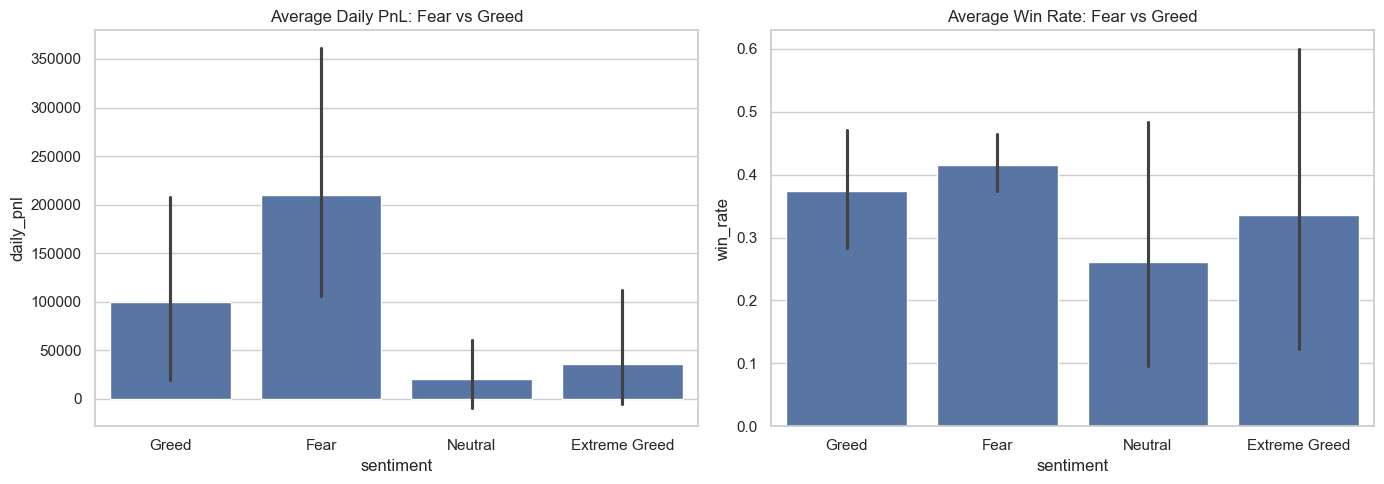

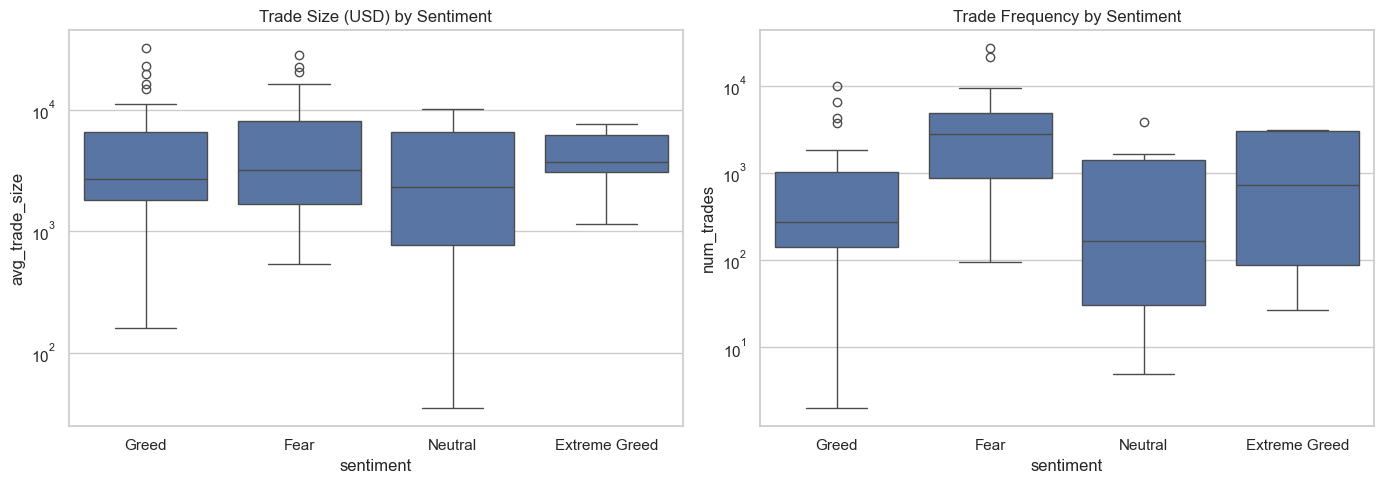

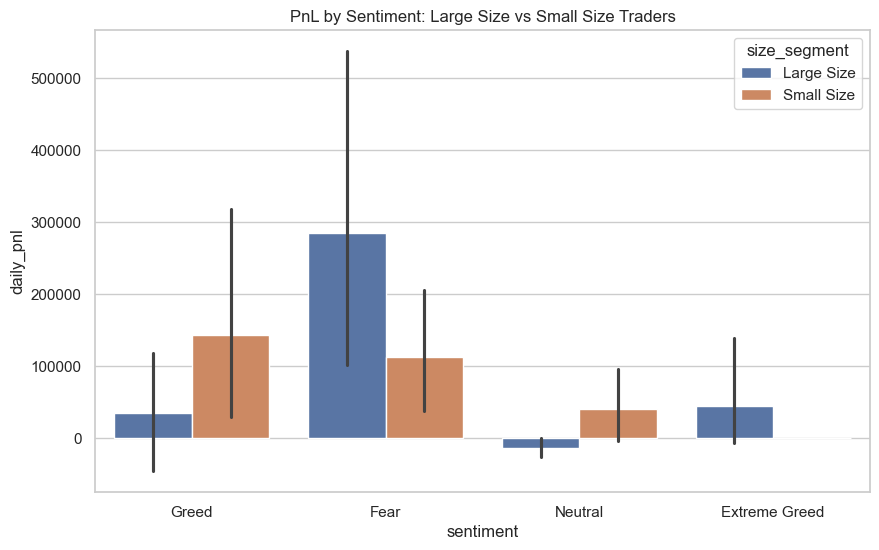

In [12]:


# Question 1: Does performance change between Fear vs Greed days?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=daily_metrics, x='sentiment', y='daily_pnl', ax=axes[0])
axes[0].set_title('Average Daily PnL: Fear vs Greed')

sns.barplot(data=daily_metrics, x='sentiment', y='win_rate', ax=axes[1])
axes[1].set_title('Average Win Rate: Fear vs Greed')
plt.tight_layout()
plt.show()

# Question 2: Does behavior change based on sentiment? 
# (Checking Trade Size and Frequency since Leverage is absent in dataset)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=daily_metrics, x='sentiment', y='avg_trade_size', ax=axes[0])
axes[0].set_title('Trade Size (USD) by Sentiment')
axes[0].set_yscale('log')

sns.boxplot(data=daily_metrics, x='sentiment', y='num_trades', ax=axes[1])
axes[1].set_title('Trade Frequency by Sentiment')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

# Question 3: Segmenting the traders
# Splitting by median Trade Size to compare High-Volume (Whales) vs Low-Volume (Retail) traders
median_size = daily_metrics['avg_trade_size'].median()
daily_metrics['size_segment'] = np.where(daily_metrics['avg_trade_size'] > median_size, 'Large Size', 'Small Size')

plt.figure(figsize=(10, 6))
sns.barplot(data=daily_metrics, x='sentiment', y='daily_pnl', hue='size_segment')
plt.title('PnL by Sentiment: Large Size vs Small Size Traders')
plt.show()

## Bonus: Clustering & Prediction
Identifying behavioral archetypes using K-Means clustering, and predicting daily profitability using a Random Forest Classifier.

In [13]:

# 1. Behavioral archetypes using K-Means on average lifetime stats
trader_profiles = daily_metrics.groupby('Account').agg({
    'num_trades': 'mean',
    'avg_trade_size': 'mean',
    'win_rate': 'mean'
}).fillna(0)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_profiles = scaler.fit_transform(trader_profiles)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_profiles['Archetype'] = kmeans.fit_predict(scaled_profiles)
print("Archetype Distribution:")
print(trader_profiles['Archetype'].value_counts())

# 2. Predict if a trader will make money tomorrow based on behavior + sentiment
ml_data = daily_metrics.dropna().copy()
ml_data['is_profitable'] = (ml_data['daily_pnl'] > 0).astype(int)

# Prep features for the Random Forest
ml_data = pd.get_dummies(ml_data, columns=['sentiment'], drop_first=True)
features = ['avg_trade_size', 'ls_ratio', 'num_trades'] + [col for col in ml_data.columns if 'sentiment_' in col]

X = ml_data[features]
y = ml_data['is_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42) 
clf.fit(X_train, y_train)

print("\nRandom Forest Predictor Results (Profitable vs Unprofitable Day):")
print(classification_report(y_test, clf.predict(X_test)))

Archetype Distribution:
Archetype
2    14
0    14
1     4
Name: count, dtype: int64

Random Forest Predictor Results (Profitable vs Unprofitable Day):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.67      0.91      0.77        11

    accuracy                           0.62        16
   macro avg       0.33      0.45      0.38        16
weighted avg       0.46      0.62      0.53        16

